In [162]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [163]:
data = pd.read_csv('ML data.csv')

In [164]:
data.shape

(315, 197)

In [165]:
data.describe()

,age,organism_isolated,first_oxacillin,first_tigecycline,first_ampicillin_Tazobactam,sec_nitrofurantoin,sec_azithromycin,sec_polymyxin_ b,num_organis,date_at_discharge,length_hosp_stay
count,314.000000,315.000000,0.0,0.0,0.0,0.0,0.0,0.0,5.000000,263.000000,314.000000
mean,32.589172,1.206349,NaN,NaN,NaN,NaN,NaN,NaN,1.400000,45229.555133,28.369427
std,22.523825,0.435624,NaN,NaN,NaN,NaN,NaN,NaN,0.547723,143.649289,48.478813
min,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,44657.000000,0.000000
25%,18.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,45118.500000,9.000000
50%,31.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,45260.000000,18.500000
75%,48.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,45339.500000,35.000000
max,95.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,45644.000000,744.000000


In [166]:
data['length_hosp_stay'].notna().sum()

314

In [167]:
data['age'].notna().sum()

314

In [168]:
data = data.dropna(subset =['age'])

In [169]:
data = data.dropna(subset =['length_hosp_stay'])

In [170]:
data.fillna('UNK')

,name_of_rrh,age,sex,hosp_48hrs,Infection_Site_1,Infection_Site_2,Infection_Site_3,oth_infect_site,referral,facility_category,...,sec_cefoxtin2,complications,me_complic,treatment_outcome,diag_death,diagnosis_at_discharge,date_death,date_at_discharge,date_referral,length_hosp_stay
0,Arua,18.0,Male,Yes,Surgical_site,UNK,UNK,Abdomil incision site,Yes,Lower-level public health facility,...,UNK,Yes,Surgical Site Infection,Cured/recovered,UNK,Sepsis without septic shock,UNK,44972.0,UNK,0.0
1,Arua,17.0,Female,Yes,Surgical_site,UNK,UNK,ABDOMIL INCISION SITE,Yes,Private health facilty,...,UNK,Yes,Peuperal Sepsis,Cured/recovered,UNK,Puerperal sepsis,UNK,45208.0,UNK,10.0
2,Arua,29.0,Male,Yes,Musculoskeletal,UNK,UNK,Lower limb,Yes,Lower-level public health facility,...,UNK,No,UNK,Cured/recovered,UNK,Diabetic foot ulcer,UNK,45257.0,UNK,69.0
3,Arua,50.0,Female,Yes,Oralcavity,UNK,UNK,Buccal cavity,Yes,Private health facilty,...,UNK,UNK,UNK,Died,Ludwig’s angi,UNK,2024-03-11T00:00:00Z,UNK,UNK,5.0
4,Arua,30.0,Female,Yes,Musculoskeletal,UNK,UNK,Right lower limb,No,UNK,...,UNK,UNK,UNK,Clinical improvement / Recovering,UNK,"Fracture of femur, unspecified, Open wound of ...",UNK,45251.0,UNK,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,Soroti,28.0,Female,Yes,Surgical_site,UNK,UNK,Abdomil Incision Site,No,UNK,...,UNK,No,UNK,Clinical improvement / Recovering,UNK,Puerperal sepsis,UNK,45210.0,UNK,20.0
311,Soroti,20.0,Female,Yes,Surgical_site,UNK,UNK,Abdomil incision Site,No,UNK,...,UNK,Yes,Surgical site infection,Clinical improvement / Recovering,UNK,Pyomyositis,UNK,45393.0,UNK,30.0
312,Soroti,27.0,Female,Yes,Abdomen,UNK,UNK,Abdomil Wall,No,UNK,...,UNK,Yes,Septic shock,Died,UNK,"Cerebral ischaemic stroke, unspecified, mening...",2024-01-29T00:00:00Z,UNK,UNK,9.0
313,Soroti,27.0,Female,Yes,Surgical_site,UNK,UNK,Abdomil Incision Site,No,UNK,...,UNK,No,UNK,Clinical improvement / Recovering,UNK,"severe plasmodium falciparum malaria, septic a...",UNK,45228.0,UNK,3.0


In [171]:
data.drop(columns= ['date_at_discharge', 'date_referral', 'date_death', 'admission_date','collection_date', 'start_date_antib', 'admission_date'], inplace = True )

In [172]:
data.drop(columns = ['growth1', 'culture_and_sensitivity'], inplace= True)

## Encoding

# Label encoding

In [173]:
from sklearn.preprocessing import LabelEncoder

Le = LabelEncoder()

In [174]:
columns_to_encode = data.drop(columns = ['age', 'length_hosp_stay', 'referral', 'sex', 'hosp_48hrs'])

In [175]:
for column in columns_to_encode:
    data[column] = Le.fit_transform(data[column])

# One hot encoding


In [176]:
#sex
data['sex'] = data['sex'].replace({'Male': 0, 'Female': 1})

/tmp/ipykernel_12132/1529081699.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['sex'] = data['sex'].replace({'Male': 0, 'Female': 1})


In [177]:
#hosp_48hrs

data['hosp_48hrs'] = data['hosp_48hrs'].replace({'Yes' : 1, 'No' : 0})

/tmp/ipykernel_12132/665312015.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['hosp_48hrs'] = data['hosp_48hrs'].replace({'Yes' : 1, 'No' : 0})


In [178]:
#referral

data['referral'] = data['referral'].replace({'Yes' : 1 , 'No': 0})

/tmp/ipykernel_12132/2176752898.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['referral'] = data['referral'].replace({'Yes' : 1 , 'No': 0})


In [179]:
#intubated

data['intubated'] = data['intubated'].replace({'Unknown': 'No'})
data['intubated'] = data['intubated'].replace({'No': 0, 'Yes':1})

In [180]:
data.head()

,name_of_rrh,age,sex,hosp_48hrs,Infection_Site_1,Infection_Site_2,Infection_Site_3,oth_infect_site,referral,facility_category,...,sec_oxacilin2,sec_penicillin_g2,sec_vanco2,sec_cefoxtin2,complications,me_complic,treatment_outcome,diag_death,diagnosis_at_discharge,length_hosp_stay
0,0,18.0,0,1,9,8,4,10,1,0,...,1,1,1,1,1,47,1,31,99,0.0
1,0,17.0,1,1,9,8,4,1,1,1,...,1,1,1,1,1,22,1,31,89,10.0
2,0,29.0,0,1,7,8,4,59,1,0,...,1,1,1,1,0,57,1,31,22,69.0
3,0,50.0,1,1,8,8,4,20,1,1,...,1,1,1,1,2,57,2,6,143,5.0
4,0,30.0,1,1,7,8,4,81,0,2,...,1,1,1,1,2,57,0,31,34,45.0


# Correlation n with the length of hospital stay

The top 20 variables that have a high correlation with the length of hospital stay

/tmp/ipykernel_12132/2251148036.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='RdBu')


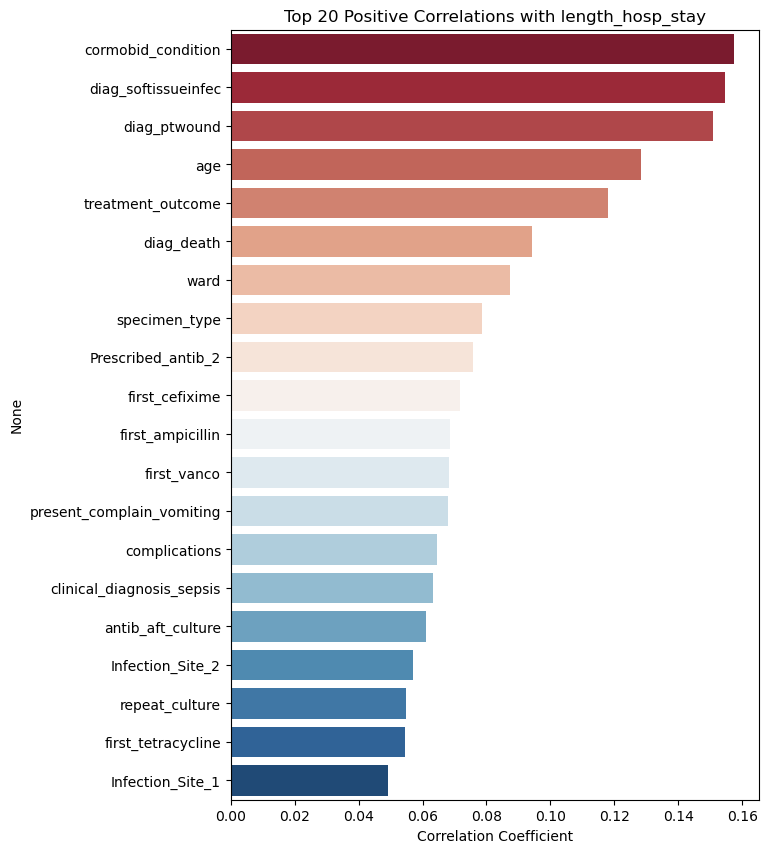

In [181]:
def plot_correlations(df, target_column, n_top=20):
    """
    Create correlation visualizations for the target variable.
    
    Parameters:
    df: pandas DataFrame containing the data
    target_column: string, name of the target/outcome variable
    n_top: int, number of top correlations to show (default 20)
    """
    
    # Calculate correlations with target variable
    correlations = df.corr()[target_column].sort_values(ascending=False)
    
    # Get top N most correlated features (excluding the target itself)
    top_corr = correlations[1:n_top+1]
    #bottom_corr = correlations[-(n_top):]
    
    # Create figure with two subplots
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Horizontal bar chart of top correlations
    plt.subplot(1, 2, 1)
    sns.barplot(x=top_corr.values, y=top_corr.index, palette='RdBu')
    plt.title(f'Top {n_top} Positive Correlations with {target_column}')
    plt.xlabel('Correlation Coefficient')
    
    # Plot 2: Horizontal bar chart of bottom correlations
    # plt.subplot(1, 2, 2)
    # sns.barplot(x=bottom_corr.values, y=bottom_corr.index, palette='RdBu')
    # plt.title(f'Top {n_top} Negative Correlations with {target_column}')
    # plt.xlabel('Correlation Coefficient')
    
    # plt.tight_layout()
    # plt.show()
    
    # Create heatmap of top correlated features
    # plt.figure(figsize=(12, 8))
    # top_features = list(top_corr.index[:10]) + [target_column]  # Top 10 + target
    # correlation_matrix = df[top_features].corr()
    
    # sns.heatmap(correlation_matrix, 
    #             annot=True,
    #             cmap='RdBu',
    #             vmin=-1, 
    #             vmax=1,
    #             center=0,
    #             fmt='.2f')
    # plt.title(f'Correlation Heatmap of Top Features with {target_column}')
    # plt.xticks(rotation=45, ha='right')
    # plt.yticks(rotation=0)
    # plt.tight_layout()
    # plt.show()

plot_correlations(data, 'length_hosp_stay', n_top=20)

In [182]:
data.to_csv('Final data.csv', index = False)